# 03 - Complete Replication Results

This notebook regenerates all CSV tables and figures from the reusable source code. Run it from top to bottom before committing a final version.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image, display
from src.replication import run_full_replication

outputs = run_full_replication(ROOT / "results")
print("All tables and figures regenerated successfully.")

All tables and figures regenerated successfully.


## Audit of the paper's reported exact values

In [2]:
outputs["audit"].round(6)

,table,maturity,spot,strike,paper_exact,standard_call,standard_put,call_gap,put_gap,closest_standard_formula
0,Table 1 - call,3M,5.0,5.5,0.09737,0.099025,0.530703,0.001655,0.433333,call
1,Table 1 - call,6M,5.0,5.5,0.13606,0.211289,0.575494,0.075229,0.439434,call
2,Table 1 - call,1Y,5.0,5.5,0.40131,0.401319,0.633081,0.000009,0.231771,call
3,Table 2 - call,3M,7.0,7.5,0.18895,0.191559,0.598393,0.002609,0.409443,call
4,Table 2 - call,6M,7.0,7.5,0.24914,0.362185,0.677010,0.113045,0.427870,call
5,Table 2 - call,1Y,7.0,7.5,0.63791,0.637918,0.772139,0.000008,0.134229,call
6,Table 3 - labelled put,3M,5.5,5.0,0.63017,0.632073,0.069962,0.001903,0.560208,call
7,Table 3 - labelled put,6M,5.5,5.0,0.75512,0.758319,0.134869,0.003199,0.620251,call
8,Table 3 - labelled put,1Y,5.5,5.0,0.96525,0.965255,0.221402,0.000005,0.743848,call
9,Table 4 - labelled put,3M,7.5,7.0,0.72335,0.726200,0.139245,0.002850,0.584105,call


## Independent and reported method comparison

In [3]:
outputs["comparison"].round(6)

,maturity,method,price,absolute_error_vs_standard_bs,elapsed_seconds
0,3M,Analytical Black-Scholes,0.099025,0.000000,0.000000
1,3M,Explicit FDM,0.099300,0.000274,0.003336
2,3M,Crank-Nicolson,0.099293,0.000267,0.031199
3,3M,Monte Carlo,0.099774,0.000749,0.002208
4,3M,Paper reported exact,0.097370,0.001655,NaN
5,3M,Paper reported MCFDM,0.095430,0.003595,NaN
6,3M,Paper reported CFDM,0.069310,0.029715,NaN
7,3M,Paper reported Monte Carlo,0.094640,0.004385,NaN
8,6M,Analytical Black-Scholes,0.211289,0.000000,0.000000
9,6M,Explicit FDM,0.211317,0.000028,0.003864


## Convection sensitivity

In [4]:
outputs["sensitivity"].round(6)

,theta,price,absolute_error,elapsed_seconds
0,0.75,0.095054,0.003972,0.003566
1,0.90,0.097585,0.001441,0.003076
2,1.00,0.099300,0.000274,0.003723
3,1.10,0.101037,0.002012,0.003596
4,1.25,0.103686,0.004661,0.004577


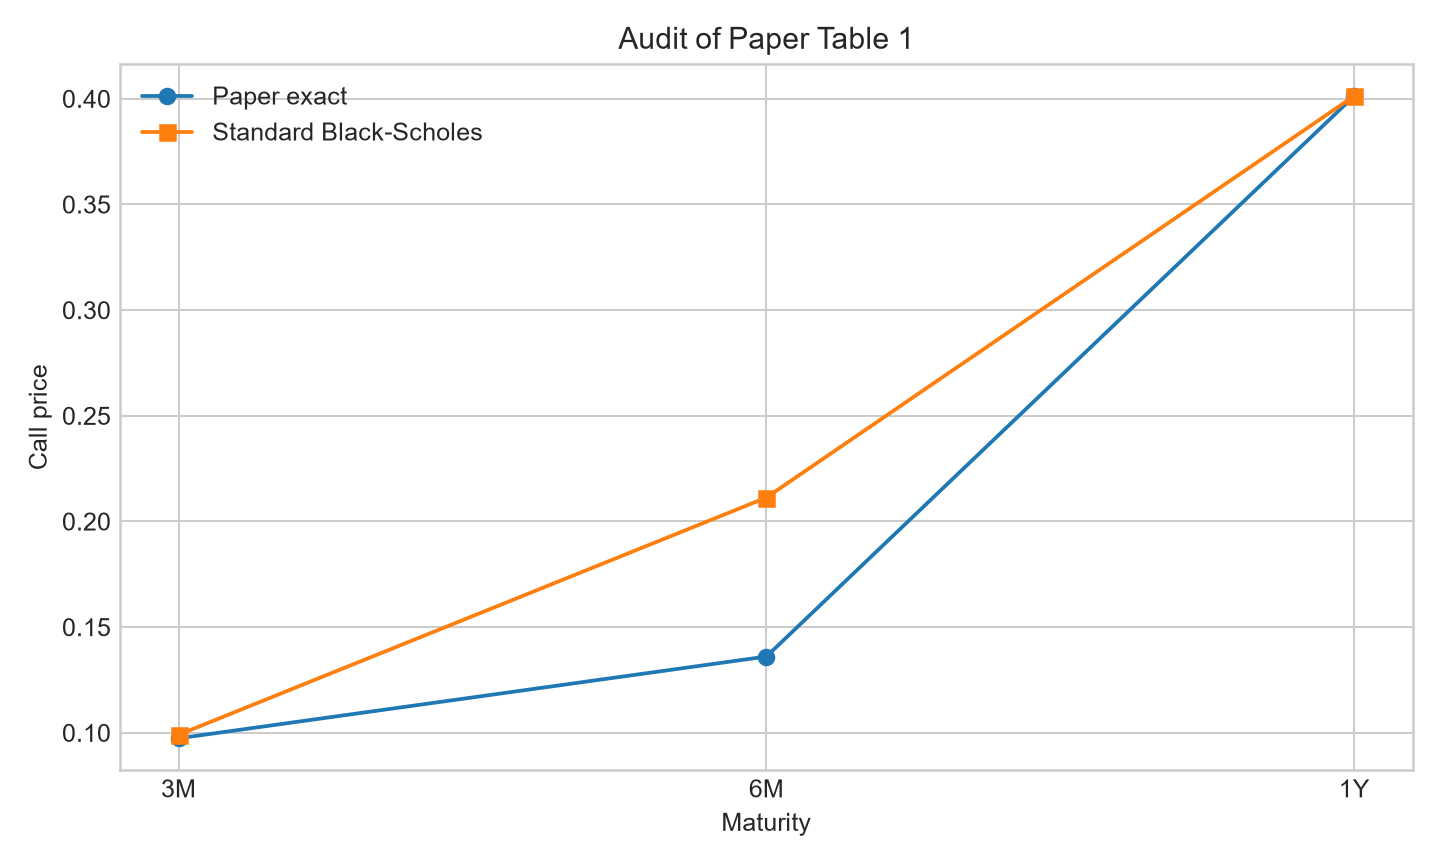

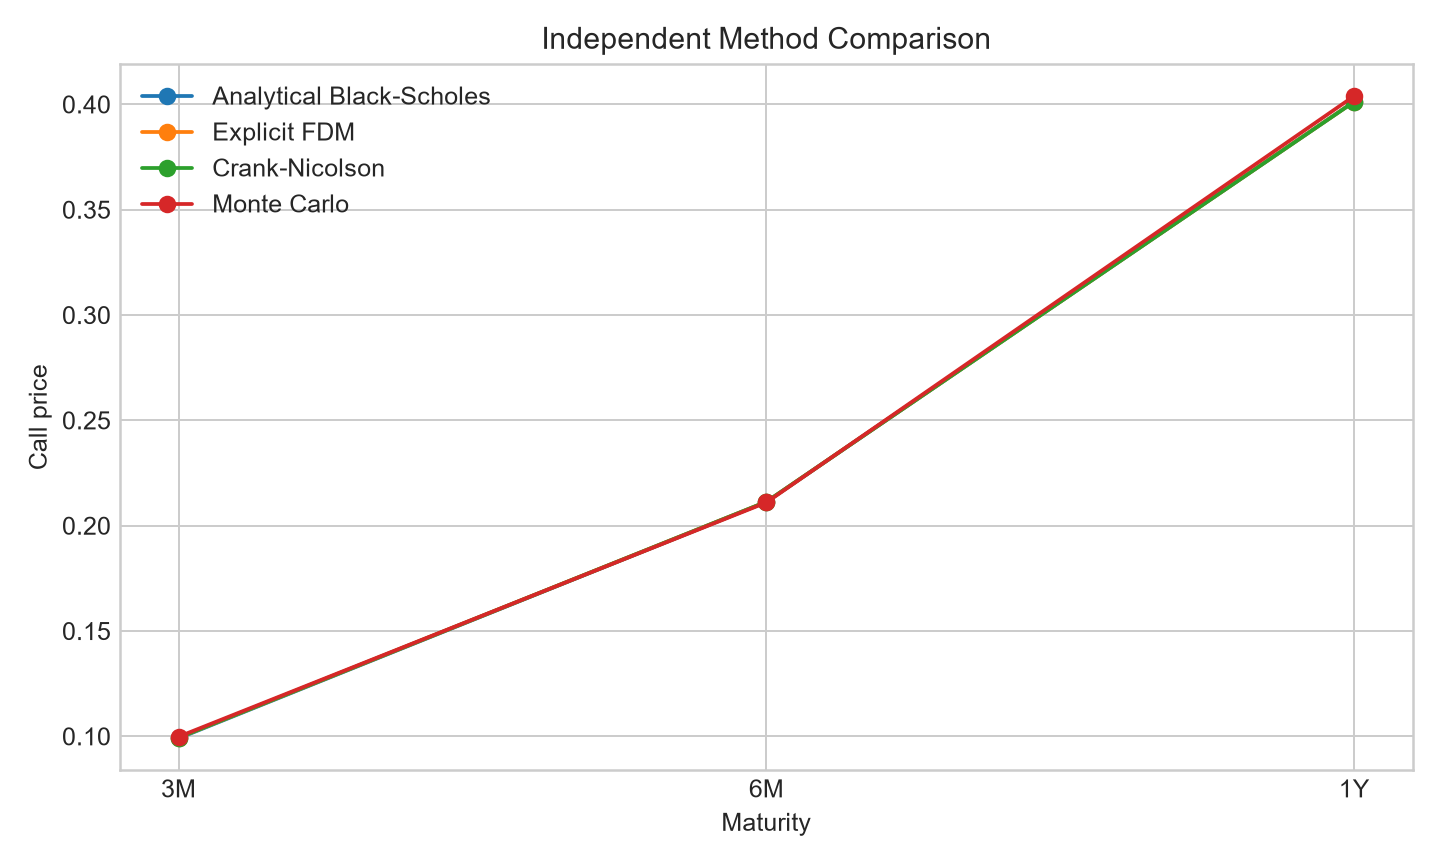

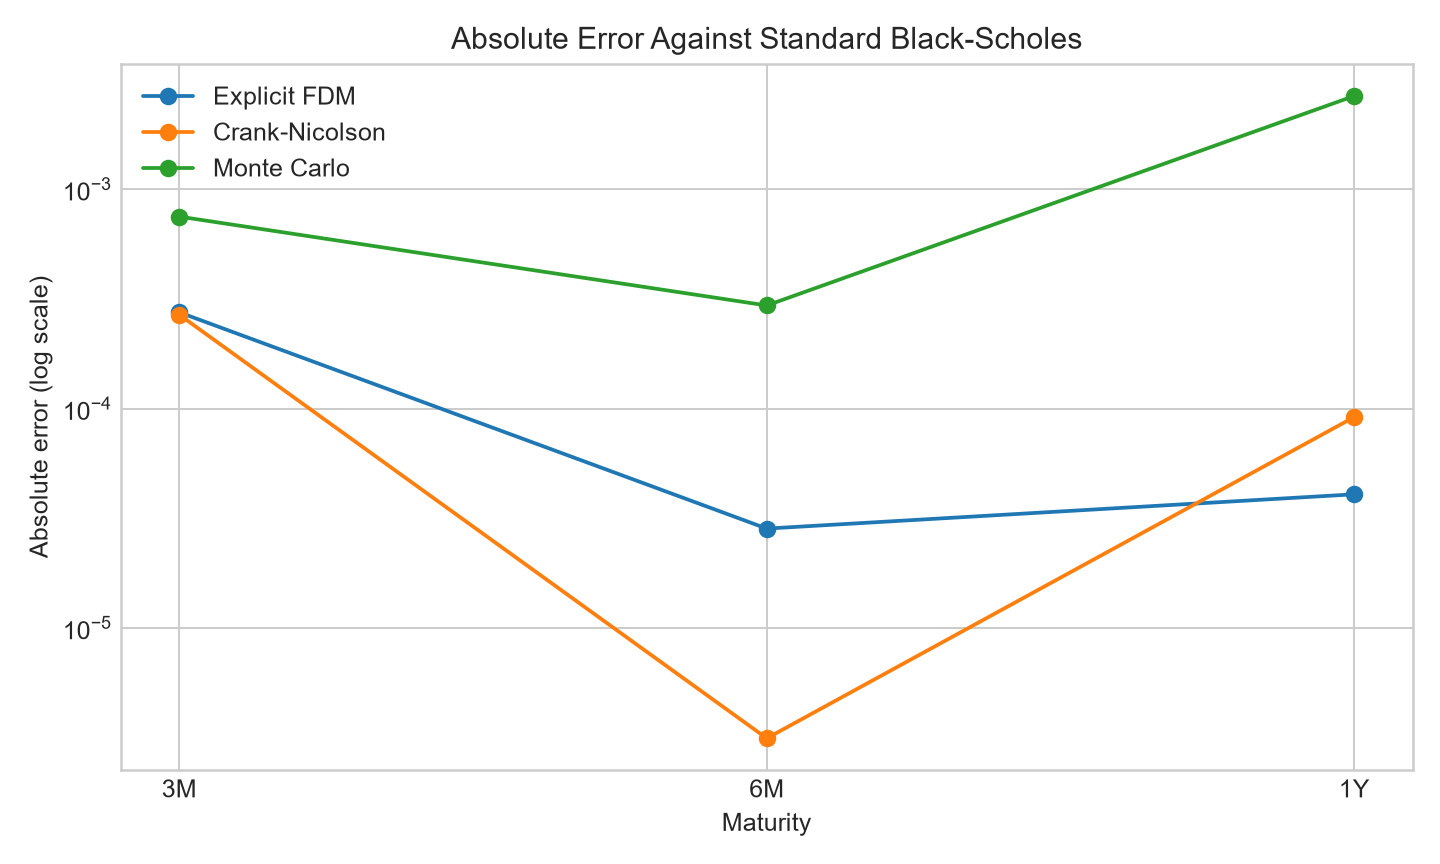

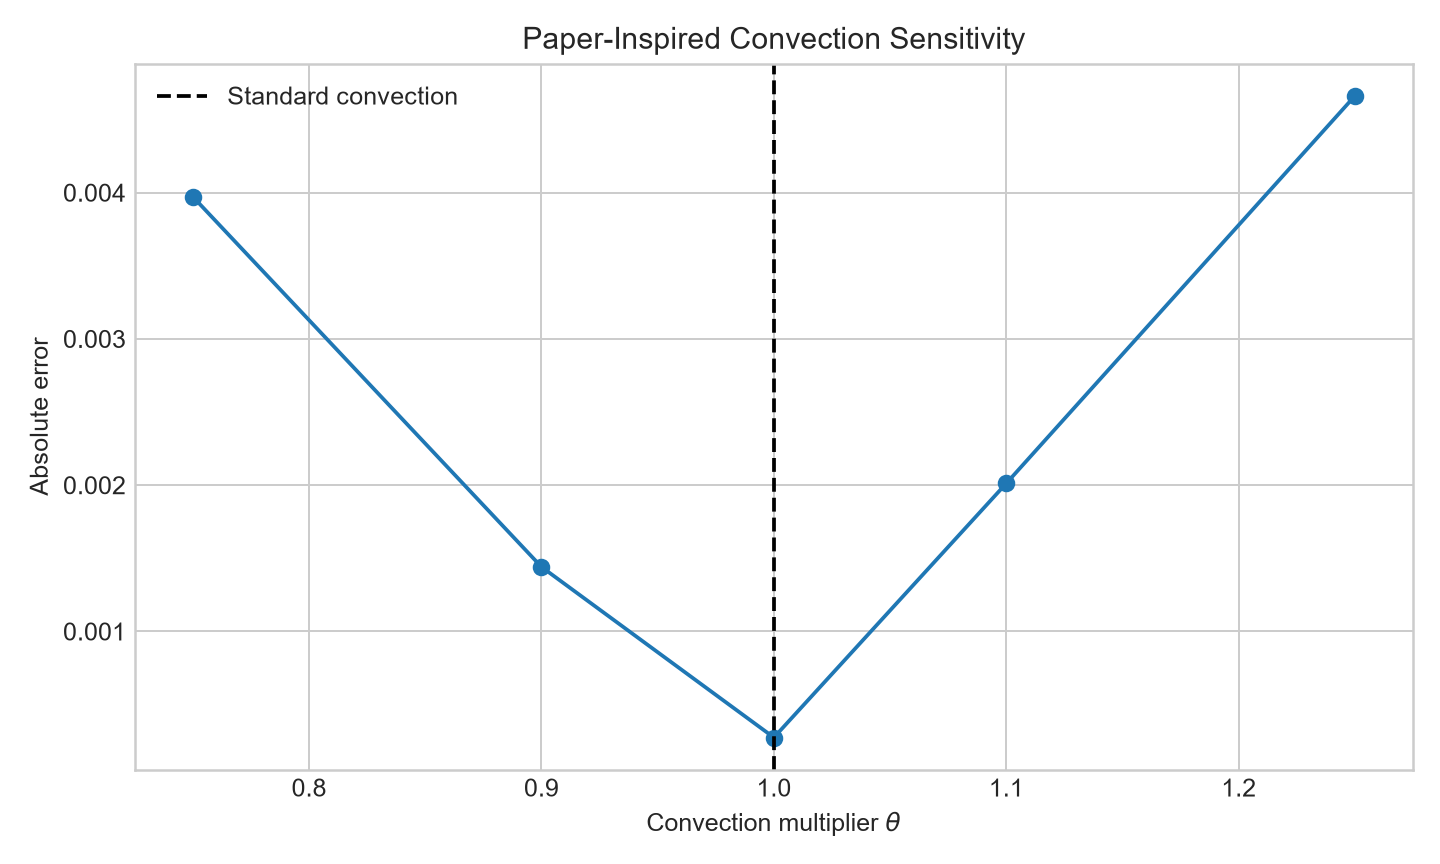

In [5]:
for filename in [
    "paper_table1_audit.png",
    "independent_method_comparison.png",
    "independent_method_errors.png",
    "convection_sensitivity.png",
]:
    display(Image(filename=str(ROOT / "results" / "figures" / filename)))

## Final conclusions

1. Conventional explicit FDM and Crank-Nicolson reproduce the analytical Black-Scholes benchmark closely on the stated grid.
2. The paper's six-month exact call values cannot be reproduced from its stated parameters.
3. The tables labelled as puts numerically resemble calls under the narrative spot/strike settings.
4. Monte Carlo results vary with the random sample, so a seed, standard error, and confidence interval are required.
5. The reported MCFDM cannot be uniquely reconstructed because essential operators and tuning-function details are missing.

The strongest outcome is therefore a transparent critical replication: working numerical methods, quantified error, reproducible tests, and documented limits on what the source paper allows another researcher to reproduce.